# 01 — Explore

**Goal of this notebook:** look at the raw data and plot hold-time distributions
for one PD subject and one control.

Do not model anything here. Just look.

In [2]:
import sys, numpy, pandas
print(sys.executable)
print(numpy.__version__, pandas.__version__)

c:\Users\ASUS\Desktop\keystroke-pd\.venv\Scripts\python.exe
2.5.3 3.0.5


In [3]:
# 2. Load it into a DataFrame. Compute hold_time = release - press.
#    Print .describe(). Do the numbers look physically plausible?


In [4]:
# 3. Histogram of hold_time for one PD subject and one control, overlaid.
#    Label your axes. Include units.


In [5]:
path = "../data/raw/neuroqwerty/MIT-CS1PD/data_MIT-CS1PD/1401114972.068_001_014.csv"
with open(path) as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(line.rstrip())

"e",1401114972.0134,0.0652,-1401114971.9481
"n",0.1194,1.9508,1.8314
"t",0.1337,2.5555,2.4218
"e",0.1847,3.0796,2.8949
"r",0.1499,3.3912,3.2413
"o",0.2137,4.1754,3.9616
"comma",0.1643,6.6316,6.4673
"space",0.1511,8.0693,7.9182
"q",0.1850,10.6346,10.4495
"u",0.1344,10.8587,10.7244
"e",0.1865,11.3900,11.2035
"space",0.1306,11.7202,11.5896
"v",0.1712,12.6209,12.4497
"i",0.1460,12.8828,12.7368
"o",0.1424,13.2333,13.0909
"space",0.1167,14.2082,14.0914
"a",0.1776,14.8200,14.6424
"space",0.1172,15.4463,15.3292
"s",0.1829,15.8854,15.7024
"u",0.1478,16.2464,16.0986


In [6]:
import pandas as pd

cols = ["key", "hold", "release", "press"]
df = pd.read_csv(path, header=None, names=cols)

df["hold_calc"] = df["release"] - df["press"]
df["mismatch"] = (df["hold_calc"] - df["hold"]).abs()

print(df.shape)
print(df[["hold", "hold_calc", "mismatch"]].describe())

(1028, 6)
               hold     hold_calc      mismatch
count  1.028000e+03  1.028000e+03  1.028000e+03
mean   1.362952e+06  1.362952e+06  2.373531e-05
std    4.369958e+07  4.369958e+07  4.256664e-05
min    9.290000e-02  9.290000e-02  0.000000e+00
25%    1.308000e-01  1.308000e-01  9.270362e-15
50%    1.480500e-01  1.480000e-01  2.942091e-14
75%    1.640250e-01  1.640000e-01  9.008766e-14
max    1.401115e+09  1.401115e+09  1.000000e-04


In [7]:
bad = (df["press"] <= 0) | (df["release"] <= 0) | (df["hold"] < 0) | (df["hold"] >= 5)
print("dropped:", bad.sum(), "of", len(df), f"({bad.mean():.2%})")

clean = df[~bad]
print(clean["hold"].describe())

dropped: 1 of 1028 (0.10%)
count    1027.00000
mean        0.15215
std         0.06343
min         0.09290
25%         0.13080
50%         0.14800
75%         0.16400
max         1.41410
Name: hold, dtype: float64


In [8]:
print(clean.nlargest(8, "hold")[["key", "hold", "press"]])
print()
print(clean["key"].value_counts().head(12))

         key    hold     press
319  Shift_L  1.4141  268.9152
314  Shift_L  1.0453  264.1920
852  Shift_L  0.9172  747.6801
557  Shift_L  0.7170  499.4231
327  Shift_L  0.6465  277.9919
690        a  0.2768  623.0889
739        a  0.2552  661.5095
185        b  0.2543  159.2540

key
space    173
e        109
a        105
o         89
s         67
n         47
r         46
d         46
l         42
i         39
c         35
u         34
Name: count, dtype: int64


In [9]:
is_modifier = clean["key"].str.match(r"^(Shift|Alt|Control)")
is_mouse = clean["key"].str.startswith("mouse")

keys = clean[~is_modifier & ~is_mouse]
print("removed:", (is_modifier | is_mouse).sum(), "rows;", len(keys), "left")
print(keys["hold"].describe())

removed: 5 rows; 1022 left
count    1022.000000
mean        0.148256
std         0.023700
min         0.092900
25%         0.130800
50%         0.148000
75%         0.163900
max         0.276800
Name: hold, dtype: float64


Matplotlib is building the font cache; this may take a moment.


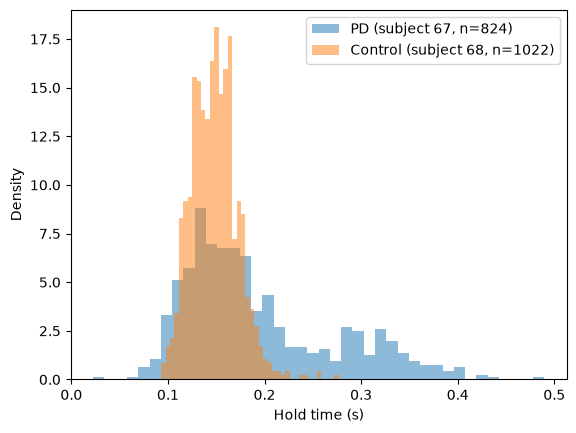

PD     median/std: 0.16935 0.07813144701188704
Control median/std: 0.148 0.023699580997335302


In [10]:
import matplotlib.pyplot as plt

base = "../data/raw/neuroqwerty/MIT-CS1PD/data_MIT-CS1PD/"

def load_hold_times(fname):
    d = pd.read_csv(base + fname, header=None, names=["key", "hold", "release", "press"])
    d = d[(d["press"] > 0) & (d["release"] > 0) & (d["hold"] >= 0) & (d["hold"] < 5)]
    d = d[~d["key"].str.match(r"^(Shift|Alt|Control)") & ~d["key"].str.startswith("mouse")]
    return d["hold"]

pd_hold = load_hold_times("1401117235.067_001_014.csv")
hc_hold = load_hold_times("1401114972.068_001_014.csv")

plt.hist(pd_hold, bins=40, alpha=0.5, label=f"PD (subject 67, n={len(pd_hold)})", density=True)
plt.hist(hc_hold, bins=40, alpha=0.5, label=f"Control (subject 68, n={len(hc_hold)})", density=True)
plt.xlabel("Hold time (s)")
plt.ylabel("Density")
plt.legend()
plt.savefig("../results/hold_time_distributions.png", dpi=150)
plt.show()

print("PD     median/std:", pd_hold.median(), pd_hold.std())
print("Control median/std:", hc_hold.median(), hc_hold.std())

In [11]:
d67 = pd.read_csv(base + "1401117235.067_001_014.csv", header=None,
                  names=["key", "hold", "release", "press"])
d67 = d67[(d67["press"] > 0) & (d67["release"] > 0) & (d67["hold"] >= 0) & (d67["hold"] < 5)]
d67 = d67[~d67["key"].str.match(r"^(Shift|Alt|Control)") & ~d67["key"].str.startswith("mouse")]

tail = d67[d67["hold"] > 0.25]
print(len(tail), "of", len(d67), "holds are > 0.25 s")
print(tail["key"].value_counts().head(10))
print()
print(d67["key"].value_counts().head(10))

187 of 824 holds are > 0.25 s
key
a        58
e        43
s        34
q        16
d        15
c         7
r         5
space     5
g         1
f         1
Name: count, dtype: int64

key
space    151
e         96
o         72
a         69
s         57
n         47
r         42
u         40
d         39
l         33
Name: count, dtype: int64
